# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b>Pandas_InClass_7_(Filling Null Values with Fillna)</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to be informed about the innovations, please do not forget to follow us.</b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [Whatsapp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [Linkedin](https://www.linkedin.com/company/techproeducation/mycompany/) |

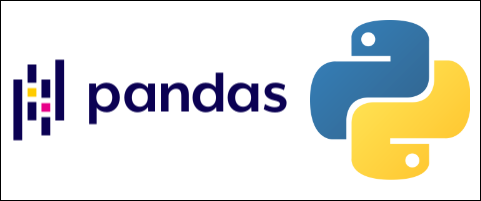

# <font color='green'> <b>Importing Libraries </b><font color='black'>

The **filter()** function is used to retrieve a subset of the data frame or series based on column or row labels. This is useful when you want to select specific columns or rows.

The **where()** function is used to preserve values that meet a certain condition in a data frame or series. Values that do not meet the condition are either NaN (the default) or can optionally be replaced with another value.

[Pandas Official Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.filter.html),
[SOURCE01](https://www.sharpsightlabs.com/blog/pandas-filter/),
[SOURCE02](https://appdividend.com/2020/03/19/pandas-filter-pandas-dataframe-filter-in-python-example/),
[SOURCE03](https://www.geeksforgeeks.org/python-pandas-dataframe-where/)
    
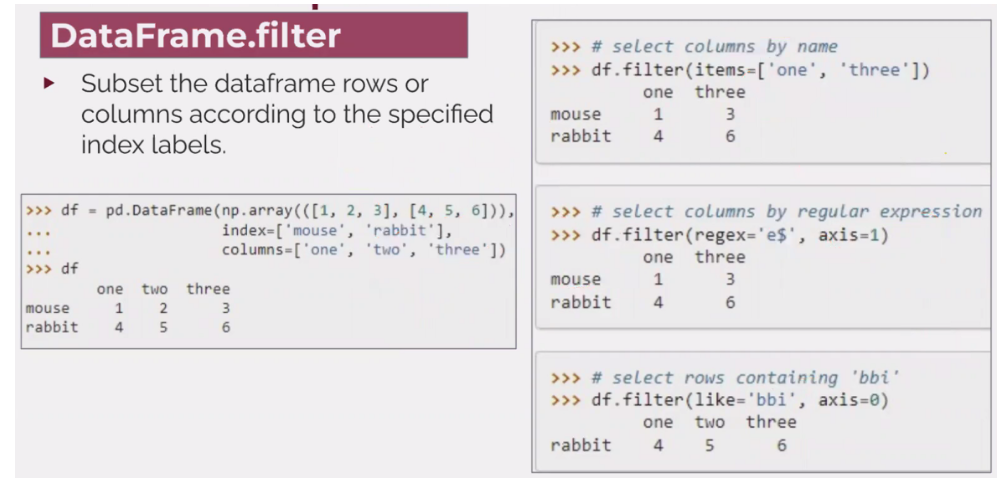
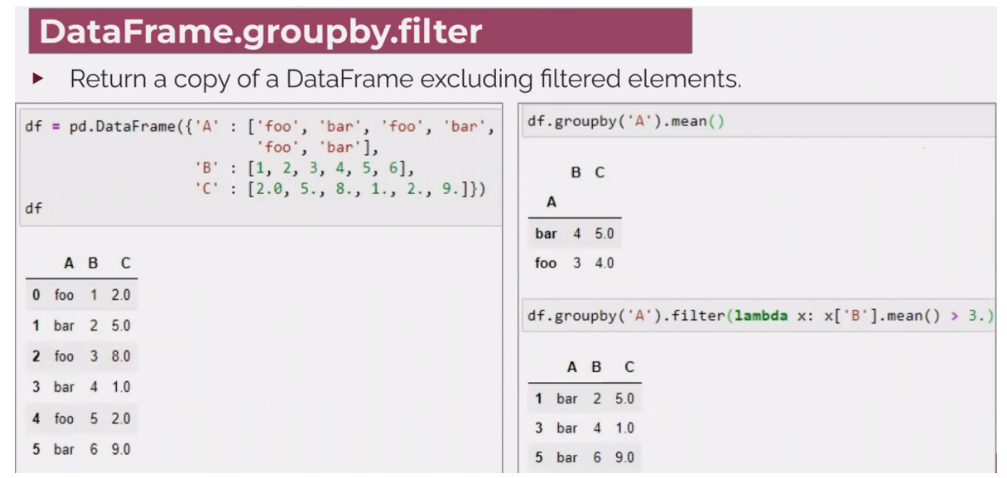

In [91]:
df

,Company,Department,Person,Age,Salary
0,Google,Engineering,Alice,29,100000
1,Google,HR,Bob,35,8000
2,Microsoft,Engineering,Charlie,32,13500
3,Microsoft,HR,David,45,90000
4,Amazon,Engineering,Eve,28,1250
5,Amazon,HR,Frank,38,85000
6,Google,HR,Grace,41,950
7,Amazon,Engineering,Hannah,30,1280
8,Microsoft,HR,Ivy,36,8700
9,Google,Engineering,Jack,27,10100


In [92]:
df.groupby('Company')[['Age']].mean()

,Age
Company,
Amazon,32.000000
Google,33.000000
Microsoft,37.666667


In [94]:
df

,Company,Department,Person,Age,Salary
0,Google,Engineering,Alice,29,100000
1,Google,HR,Bob,35,8000
2,Microsoft,Engineering,Charlie,32,13500
3,Microsoft,HR,David,45,90000
4,Amazon,Engineering,Eve,28,1250
5,Amazon,HR,Frank,38,85000
6,Google,HR,Grace,41,950
7,Amazon,Engineering,Hannah,30,1280
8,Microsoft,HR,Ivy,36,8700
9,Google,Engineering,Jack,27,10100


In [93]:
df.groupby('Company').filter(lambda x : x['Age'].mean() < 35)

# This returns all the data that satisfies the condition in the filter lambda. 

,Company,Department,Person,Age,Salary
0,Google,Engineering,Alice,29,100000
1,Google,HR,Bob,35,8000
4,Amazon,Engineering,Eve,28,1250
5,Amazon,HR,Frank,38,85000
6,Google,HR,Grace,41,950
7,Amazon,Engineering,Hannah,30,1280
9,Google,Engineering,Jack,27,10100


In [6]:
df.groupby('Company').filter(lambda x : x['Age'].mean() < 35)['Salary']

0    100000
1      8000
4      1250
5     85000
6       950
7      1280
9     10100
Name: Salary, dtype: int64

In [7]:
df.groupby('Company')['Salary'].mean()

Company
Amazon       29176.666667
Google       29762.500000
Microsoft    37400.000000
Name: Salary, dtype: float64

In [8]:
df.groupby('Company').filter(lambda x: x['Salary'].mean() > 30000)

,Company,Department,Person,Age,Salary
2,Microsoft,Engineering,Charlie,32,13500
3,Microsoft,HR,David,45,90000
8,Microsoft,HR,Ivy,36,8700


In [9]:
df[df.Age < 35]

,Company,Department,Person,Age,Salary
0,Google,Engineering,Alice,29,100000
2,Microsoft,Engineering,Charlie,32,13500
4,Amazon,Engineering,Eve,28,1250
7,Amazon,Engineering,Hannah,30,1280
9,Google,Engineering,Jack,27,10100


In [10]:
df.where(df.Age < 35) 
# where function returns whole dataframe 
# but 
# when the condition is not satisfied, it returns the data as NaN 

,Company,Department,Person,Age,Salary
0,Google,Engineering,Alice,29.0,100000.0
1,NaN,NaN,NaN,NaN,NaN
2,Microsoft,Engineering,Charlie,32.0,13500.0
3,NaN,NaN,NaN,NaN,NaN
4,Amazon,Engineering,Eve,28.0,1250.0
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,Amazon,Engineering,Hannah,30.0,1280.0
8,NaN,NaN,NaN,NaN,NaN
9,Google,Engineering,Jack,27.0,10100.0


In [12]:
df.where(df.Age < 35, 0) #instead of NaN it returns 0 

,Company,Department,Person,Age,Salary
0,Google,Engineering,Alice,29,100000
1,0,0,0,0,0
2,Microsoft,Engineering,Charlie,32,13500
3,0,0,0,0,0
4,Amazon,Engineering,Eve,28,1250
5,0,0,0,0,0
6,0,0,0,0,0
7,Amazon,Engineering,Hannah,30,1280
8,0,0,0,0,0
9,Google,Engineering,Jack,27,10100


In [14]:
df.where(df.Age < 35).dropna() # returns the data which satisfies the condition, and the rest of them will be dropped

,Company,Department,Person,Age,Salary
0,Google,Engineering,Alice,29.0,100000.0
2,Microsoft,Engineering,Charlie,32.0,13500.0
4,Amazon,Engineering,Eve,28.0,1250.0
7,Amazon,Engineering,Hannah,30.0,1280.0
9,Google,Engineering,Jack,27.0,10100.0


## <font color='blue'> <b>Filling Missing Values (Imputation)</b><font color='black'>

### <font color='orange'> <b>Filling Numeric Variables</b><font color='orange'>

In [1]:
import numpy as np 
import pandas as pd 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
id_no = ["P001", "P002", "P003", "P004", "P005", "P006", "P007", "P008", "P009", "P010", "P011"]
gender = ["M", "F", "M", "F", "M", "F", "M", "F", "M", "F", "M"]
status = ["FT", "PT", "-", "FT", "PT", "PT", "FT", "-", "PT", "FT", np.nan]
dept = ["DS", "FS", "AWS", "AWS", "DS", None, "FS", "FS", np.nan, "DS", "AWS"]
V1 = np.array([2, 3, 5, np.nan, 7, 1, np.nan, 10, 14, "-", 6])
V2 = np.array([8, np.nan, 5, 8, 11, np.nan, np.nan, 2, 3, 7, 9])
salary = np.array([np.nan, 54, 59, 120, 58, 75, None, 136, 60, 125, np.nan])

df0 = pd.DataFrame({
                   "id" : id_no,
                   "gender": gender,
                   "status": status,
                   "dept": dept,
                   "var1" : V1,
                   "var2" : V2,
                   "salary" : salary
                  })
df0

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2,8.0,NaN
1,P002,F,PT,FS,3,NaN,54
2,P003,M,-,AWS,5,5.0,59
3,P004,F,FT,AWS,nan,8.0,120
4,P005,M,PT,DS,7,11.0,58
5,P006,F,PT,None,1,NaN,75
6,P007,M,FT,FS,nan,NaN,None
7,P008,F,-,FS,10,2.0,136
8,P009,M,PT,NaN,14,3.0,60
9,P010,F,FT,DS,-,7.0,125


In [4]:
df = df0.copy()
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2,8.0,NaN
1,P002,F,PT,FS,3,NaN,54
2,P003,M,-,AWS,5,5.0,59
3,P004,F,FT,AWS,nan,8.0,120
4,P005,M,PT,DS,7,11.0,58
5,P006,F,PT,None,1,NaN,75
6,P007,M,FT,FS,nan,NaN,None
7,P008,F,-,FS,10,2.0,136
8,P009,M,PT,NaN,14,3.0,60
9,P010,F,FT,DS,-,7.0,125


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11 non-null     object 
 1   gender  11 non-null     object 
 2   status  10 non-null     object 
 3   dept    9 non-null      object 
 4   var1    11 non-null     object 
 5   var2    8 non-null      float64
 6   salary  8 non-null      object 
dtypes: float64(1), object(6)
memory usage: 748.0+ bytes


In [6]:
df.head(2)

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2,8.0,NaN
1,P002,F,PT,FS,3,NaN,54


In [7]:
df = df.replace('-', np.nan)
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2,8.0,NaN
1,P002,F,PT,FS,3,NaN,54.0
2,P003,M,NaN,AWS,5,5.0,59.0
3,P004,F,FT,AWS,nan,8.0,120.0
4,P005,M,PT,DS,7,11.0,58.0
5,P006,F,PT,None,1,NaN,75.0
6,P007,M,FT,FS,nan,NaN,NaN
7,P008,F,NaN,FS,10,2.0,136.0
8,P009,M,PT,NaN,14,3.0,60.0
9,P010,F,FT,DS,NaN,7.0,125.0


In [8]:
df.var1 = df.var1.astype('float')
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,NaN,54.0
2,P003,M,NaN,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,NaN,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,None,1.0,NaN,75.0
6,P007,M,FT,FS,NaN,NaN,NaN
7,P008,F,NaN,FS,10.0,2.0,136.0
8,P009,M,PT,NaN,14.0,3.0,60.0
9,P010,F,FT,DS,NaN,7.0,125.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11 non-null     object 
 1   gender  11 non-null     object 
 2   status  8 non-null      object 
 3   dept    9 non-null      object 
 4   var1    8 non-null      float64
 5   var2    8 non-null      float64
 6   salary  8 non-null      float64
dtypes: float64(3), object(4)
memory usage: 748.0+ bytes


In [10]:
df.isnull().sum().sum()

np.int64(14)

In [11]:
df.head(1)

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN


In [ ]:
# when there is a nan value in a numeric column how to fill in ?
# Mean -> aritmetic average might be sensible most of the time , but if your data set is small and you have outliers,
# it might be more sensible to use median instead of mean. because median is not effected from outliers.
# According to the data set that you have , you will need to decide what to use.

In [ ]:
df.fillna(0)
# It will fill all the null values of the dataframe with the given data 
# Will not be permenant because of inplace = False
# We have to choose wise strategies to fill null values which 0 isint

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,0.0
1,P002,F,PT,FS,3.0,0.0,54.0
2,P003,M,0,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,0.0,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,0,1.0,0.0,75.0
6,P007,M,FT,FS,0.0,0.0,0.0
7,P008,F,0,FS,10.0,2.0,136.0
8,P009,M,PT,0,14.0,3.0,60.0
9,P010,F,FT,DS,0.0,7.0,125.0


In [14]:
df.var1.fillna(0)

0      2.0
1      3.0
2      5.0
3      0.0
4      7.0
5      1.0
6      0.0
7     10.0
8     14.0
9      0.0
10     6.0
Name: var1, dtype: float64

In [15]:
df.var1

0      2.0
1      3.0
2      5.0
3      NaN
4      7.0
5      1.0
6      NaN
7     10.0
8     14.0
9      NaN
10     6.0
Name: var1, dtype: float64

In [16]:
df.var1.mean()

np.float64(6.0)

In [17]:
avg_value = df.var1.mean()
avg_value

np.float64(6.0)

In [18]:
df.var1.fillna(avg_value)

0      2.0
1      3.0
2      5.0
3      6.0
4      7.0
5      1.0
6      6.0
7     10.0
8     14.0
9      6.0
10     6.0
Name: var1, dtype: float64

In [19]:
df.var1

0      2.0
1      3.0
2      5.0
3      NaN
4      7.0
5      1.0
6      NaN
7     10.0
8     14.0
9      NaN
10     6.0
Name: var1, dtype: float64

In [20]:
df.var1.fillna(df.var1.mean())

0      2.0
1      3.0
2      5.0
3      6.0
4      7.0
5      1.0
6      6.0
7     10.0
8     14.0
9      6.0
10     6.0
Name: var1, dtype: float64

In [22]:
df.var1

0      2.0
1      3.0
2      5.0
3      NaN
4      7.0
5      1.0
6      NaN
7     10.0
8     14.0
9      NaN
10     6.0
Name: var1, dtype: float64

In [23]:
df.var1.median()

5.5

In [24]:
df.var1.fillna(df.var1.median(), inplace = True)
#we filled the null values of var1 column with the median values and made it permanent 

In [25]:
df.var1

0      2.0
1      3.0
2      5.0
3      5.5
4      7.0
5      1.0
6      5.5
7     10.0
8     14.0
9      5.5
10     6.0
Name: var1, dtype: float64

In [28]:
df.var2.median()

7.5

In [ ]:
df.var2.fillna(df.var2.median(), inplace = True)

In [27]:
df.var2

0      8.0
1      7.5
2      5.0
3      8.0
4     11.0
5      7.5
6      7.5
7      2.0
8      3.0
9      7.0
10     9.0
Name: var2, dtype: float64

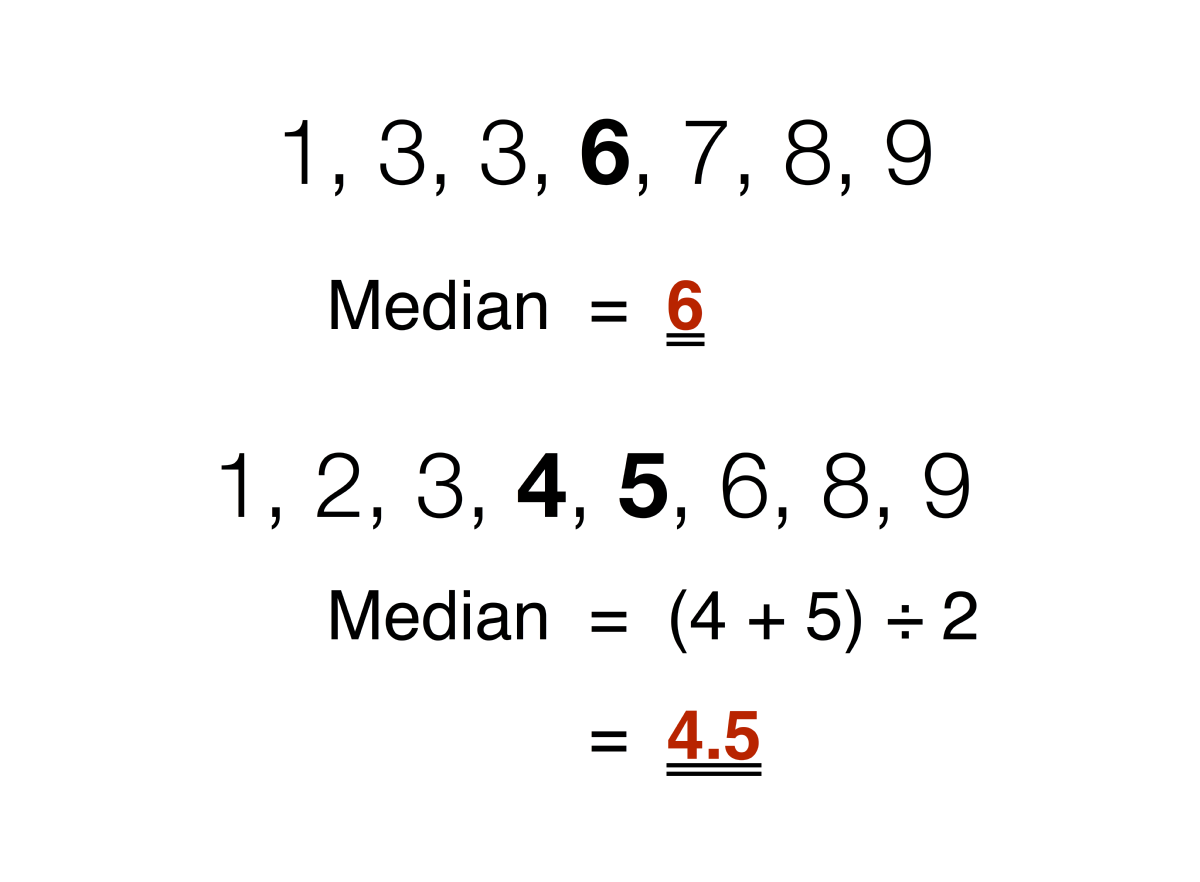

### <font color='orange'> <b>Filling Categorical Variables</b><font color='orange'>

In [ ]:
# gender -> 
# M -> Male 
# F -> Female 

# status 
# FT -> Full time 
# PT -> Part time 

# dept -> department 
# DS -> Data science 
# FS -> Full stack 
# AWS ->

# mode  -> repeats at most 
# 3 fs 
# 1 ds 
# 7 aws
# mode -> aws

In [29]:
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,NaN,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,None,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,NaN,FS,10.0,2.0,136.0
8,P009,M,PT,NaN,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [30]:
df.gender.value_counts()

gender
M    6
F    5
Name: count, dtype: int64

In [31]:
df2 = pd.read_csv('adult_eda.csv')
df2.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K


In [36]:
df2['native-country'].value_counts(dropna = False)

native-country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [37]:
df.dept.value_counts()

dept
DS     3
FS     3
AWS    3
Name: count, dtype: int64

In [38]:
df.dept.mode()

0    AWS
1     DS
2     FS
Name: dept, dtype: object

In [39]:
df.gender.mode()

0    M
Name: gender, dtype: object

In [41]:
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,NaN,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,None,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,NaN,FS,10.0,2.0,136.0
8,P009,M,PT,NaN,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [44]:
df.dept.fillna(df.dept.mode()[0])

0      DS
1      FS
2     AWS
3     AWS
4      DS
5     AWS
6      FS
7      FS
8     AWS
9      DS
10    AWS
Name: dept, dtype: object

In [45]:
df.dept

0       DS
1       FS
2      AWS
3      AWS
4       DS
5     None
6       FS
7       FS
8      NaN
9       DS
10     AWS
Name: dept, dtype: object

In [ ]:
df.dept.fillna(method = 'bfill')
# backfill --> fills the previous value with the next value

0      DS
1      FS
2     AWS
3     AWS
4      DS
5      FS
6      FS
7      FS
8      DS
9      DS
10    AWS
Name: dept, dtype: object

In [49]:
df.dept.fillna(method = 'ffill', inplace = True)
# backfill --> fills the next value with the previous value

In [51]:
df.dept

0      DS
1      FS
2     AWS
3     AWS
4      DS
5      DS
6      FS
7      FS
8      FS
9      DS
10    AWS
Name: dept, dtype: object

### <font color='orange'> <b>Filling by condition & group</b><font color='black'>

In [52]:
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,NaN,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,NaN,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [56]:
# first lets find the min, max, and average salary of full time and part time employees.
df.groupby('status')['salary'].agg([min, max, np.mean])

,min,max,mean
status,,,
FT,120.0,125.0,122.50
PT,54.0,75.0,61.75


In [58]:
df.loc[df.salary > 90, 'status']

3     FT
7    NaN
9     FT
Name: status, dtype: object

In [61]:
df.loc[df.salary > 85, 'status']

3     FT
7    NaN
9     FT
Name: status, dtype: object

In [62]:
df.loc[df.salary <= 85, 'status']

1     PT
2    NaN
4     PT
5     PT
8     PT
Name: status, dtype: object

In [65]:
df.loc[df.salary <= 90, 'status'].mode()[0]

'PT'

In [ ]:
df.loc[df.salary <= 90, 'status'].fillna(df.loc[df.salary <= 90, 'status'].mode()[0], inplace = True)

In [77]:
category_of_low_earners = df.loc[df.salary <= 90, 'status'].mode()[0]
category_of_low_earners

'PT'

In [ ]:
df.loc[df.salary <= 90, 'status'].fillna(category_of_low_earners, inplace = True)
# Go to less earners, and if there is a null value, fill it with the mode of this category.

In [ ]:
df
# even when we use inplace = True, the status hasnt changes permanently 

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,NaN,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,NaN,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [73]:
df.loc[df.salary <= 90, 'status']
# the reason is because while filling the null values we made this selection, 
# so python is filling the null values in the following selected series 
# not in the original dataframe so in these type of cases we must use reassignment technnique

1     PT
2    NaN
4     PT
5     PT
8     PT
Name: status, dtype: object

In [74]:
df.loc[df.salary <= 90, 'status'] = df.loc[df.salary <= 90, 'status'].mode()[0]
# this is the assignment technique where we select the series and asssign the pt value to the entire series 

In [75]:
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,PT,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,NaN,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [78]:
df.loc[df.salary <= 90, 'status'] = category_of_low_earners

In [79]:
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,PT,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,NaN,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [80]:
category_of_high_earners = df.loc[df.salary >= 90, 'status'].mode()[0]
category_of_high_earners

'FT'

In [ ]:
df.loc[df.salary >= 90, 'status'].fillna(df.loc[df.salary >= 90, 'status'].mode()[0])

1    PT
2    PT
4    PT
5    PT
8    PT
Name: status, dtype: object

In [ ]:
df.loc[df.salary >= 90, 'status'].fillna(category_of_high_earners, inplace = True)

In [83]:
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,PT,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,NaN,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [84]:
df.loc[df.salary >= 90, 'status'] = category_of_high_earners

In [85]:
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,PT,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,FT,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [ ]:
# when we have missing values, try to fill them with the most sensible 
# and similar values still present in the dataframe

In [86]:
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,PT,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,FT,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [97]:
df.groupby(['gender', 'dept'])['status'].unique()

gender  dept
F       AWS         [FT]
        DS      [PT, FT]
        FS      [PT, FT]
M       AWS     [PT, FT]
        DS      [FT, PT]
        FS      [FT, PT]
Name: status, dtype: object

In [94]:
df.status.fillna('FT', inplace = True)
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,NaN
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,PT,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,NaN
7,P008,F,FT,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [99]:
df.groupby(['status', 'dept'])[['salary']].mean()

salary
status dept        
FT     AWS    120.0
       DS     125.0
       FS     136.0
PT     AWS     59.0
       DS      66.5
       FS      57.0

In [106]:
filler_value = df.groupby(['status', 'dept'])['salary'].transform('mean')
filler_value

0     125.0
1      57.0
2      59.0
3     120.0
4      66.5
5      66.5
6     136.0
7     136.0
8      57.0
9     125.0
10    120.0
Name: salary, dtype: float64

In [105]:
df.salary.fillna(df.groupby(['status', 'dept'])['salary'].transform('mean'), inplace = True)
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,125.0
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,PT,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,136.0
7,P008,F,FT,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [108]:
df.salary.fillna(filler_value, inplace = True)
df

,id,gender,status,dept,var1,var2,salary
0,P001,M,FT,DS,2.0,8.0,125.0
1,P002,F,PT,FS,3.0,7.5,54.0
2,P003,M,PT,AWS,5.0,5.0,59.0
3,P004,F,FT,AWS,5.5,8.0,120.0
4,P005,M,PT,DS,7.0,11.0,58.0
5,P006,F,PT,DS,1.0,7.5,75.0
6,P007,M,FT,FS,5.5,7.5,136.0
7,P008,F,FT,FS,10.0,2.0,136.0
8,P009,M,PT,FS,14.0,3.0,60.0
9,P010,F,FT,DS,5.5,7.0,125.0


In [111]:
class LoggingDict(dict):
    def __setitem__(self, key, value):
        print('Setting %r to %r' % (key, value))
        super().__setitem__(key, value)



In [112]:
my_dict = LoggingDict({"city": "London"})
my_dict["postcode"]= "SE10"

Setting 'postcode' to 'SE10'


# <p style="background-color:green;font-family:newtimeroman;font-size:100%;color:white;text-align:center;border-radius:20px 20px;"><b>Hope It Will Be Useful, Thank You</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to be informed about the innovations, please do not forget to follow us.</b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [Whatsapp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [Linkedin](https://www.linkedin.com/company/techproeducation/mycompany/) |